In [87]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib

from tensorflow.keras import layers, Model
from scipy.signal import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [88]:
DATA_DIRS = ["../watch/src/gesture_data_filtered",
            "../watch/src/sofie_gesture_data_filtered_24",
            "../watch/src/sofie_gesture_data_filtered_28"]

WINDOW_SIZE = 128
STRIDE = 16
CHANNELS = ["ax", "ay", "az", "gx", "gy", "gz"]

# Note: removed CW / CCW, was causing too many issues
GESTURE_CODES = [
    "D",
    "De",
    "Dn",
    "Ds",
    "DUD",
    "Dw",
    "N",
    "U",
    "Ue",
    "Un",
    "Uw",
]
label_map = {code: i for i, code in enumerate(GESTURE_CODES)}
reverse_label_map = {i: code for code, i in label_map.items()}

In [89]:
def get_gesture_code(path):
    filename = os.path.basename(path)

    if filename.startswith("CCW_"):
        return "CCW"
    if filename.startswith("CW_"):
        return "CW"

    return filename.split("_")[0]

def make_windows(data, window_size=WINDOW_SIZE, stride=STRIDE):
    windows = []

    for start in range(0, len(data) - window_size + 1, stride):
        end = start + window_size
        windows.append(data[start:end])

    return windows


def load_dataset():
    X = []
    y = []
    used_files = []
    skipped_short = 0

    files = []

    for data_dir in DATA_DIRS:
        found = glob.glob(os.path.join(data_dir, "*.csv"))
        print(data_dir, "->", len(found), "CSV files")
        files.extend(found)

    print("Total CSV files found:", len(files))

    for path in files:
        gesture_code = get_gesture_code(path)

        if gesture_code not in label_map:
            continue

        df = pd.read_csv(path)

        if not all(ch in df.columns for ch in CHANNELS):
            print(f"Skipping {path}: missing IMU columns")
            continue

        data = df[CHANNELS].values.astype(np.float32)

        if len(data) < WINDOW_SIZE:
            skipped_short += 1
            continue

        windows = make_windows(data)

        for window in windows:
            X.append(window)
            y.append(label_map[gesture_code])
            used_files.append(path)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    print("Skipped short files:", skipped_short)

    return X, y, used_files

In [90]:
# Test if the data is put through for CW/CCW
X, y, used_files = load_dataset()

print("X shape:", X.shape)
print("y shape:", y.shape)

for gesture, idx in label_map.items():
    print(gesture, np.sum(y == idx))


print("Number of classes:", len(label_map))
print(label_map)
print("X shape:", X.shape)

../watch/src/gesture_data_filtered -> 1127 CSV files
../watch/src/sofie_gesture_data_filtered_24 -> 976 CSV files
../watch/src/sofie_gesture_data_filtered_28 -> 247 CSV files
Total CSV files found: 2350
Skipped short files: 841
X shape: (9032, 128, 6)
y shape: (9032,)
D 429
De 743
Dn 600
Ds 561
DUD 1083
Dw 641
N 1129
U 1386
Ue 917
Un 454
Uw 1089
Number of classes: 11
{'D': 0, 'De': 1, 'Dn': 2, 'Ds': 3, 'DUD': 4, 'Dw': 5, 'N': 6, 'U': 7, 'Ue': 8, 'Un': 9, 'Uw': 10}
X shape: (9032, 128, 6)


In [91]:
# Checking which folder the skipped files came from (chatgpt)
from collections import defaultdict
import os
import glob
import pandas as pd

DATA_DIRS = [
    "../watch/src/gesture_data_filtered",
    "../watch/src/sofie_gesture_data_filtered_24",
    "../watch/src/sofie_gesture_data_filtered_28",
]

stats = defaultdict(lambda: {"total": 0, "used": 0, "skipped": 0})

for data_dir in DATA_DIRS:
    files_in_dir = glob.glob(os.path.join(data_dir, "*.csv"))

    dataset = os.path.basename(data_dir)

    for path in files_in_dir:
        stats[dataset]["total"] += 1

        df = pd.read_csv(path)

        if len(df) < WINDOW_SIZE:
            stats[dataset]["skipped"] += 1
        else:
            stats[dataset]["used"] += 1

print(f"Window size = {WINDOW_SIZE}\n")

for dataset, s in stats.items():
    pct = 100 * s["skipped"] / s["total"] if s["total"] else 0

    print(dataset)
    print(f"  Total files   : {s['total']}")
    print(f"  Used files    : {s['used']}")
    print(f"  Skipped files : {s['skipped']}")
    print(f"  Percent skip  : {pct:.1f}%")
    print()

Window size = 128

gesture_data_filtered
  Total files   : 1127
  Used files    : 959
  Skipped files : 168
  Percent skip  : 14.9%

sofie_gesture_data_filtered_24
  Total files   : 976
  Used files    : 176
  Skipped files : 800
  Percent skip  : 82.0%

sofie_gesture_data_filtered_28
  Total files   : 247
  Used files    : 182
  Skipped files : 65
  Percent skip  : 26.3%



In [92]:
# Checking to make sure all csv files got imported
import os
import glob

DATA_DIRS = ["../watch/src/gesture_data_filtered",
            "../watch/src/sofie_gesture_data_filtered_24",
            "../watch/src/sofie_gesture_data_filtered_28"]

all_files = []

for data_dir in DATA_DIRS:
    files = glob.glob(os.path.join(data_dir, "*.csv"))

    print(data_dir)
    print("CSV files found:", len(files))

    if len(files) > 0:
        print("First few files:")
        for f in files[:5]:
            print(" ", f)

    print()
    all_files.extend(files)

print("Total CSV files found:", len(all_files))

../watch/src/gesture_data_filtered
CSV files found: 1127
First few files:
  ../watch/src/gesture_data_filtered\De_no_tremor_1.csv
  ../watch/src/gesture_data_filtered\De_no_tremor_10.csv
  ../watch/src/gesture_data_filtered\De_no_tremor_11.csv
  ../watch/src/gesture_data_filtered\De_no_tremor_12.csv
  ../watch/src/gesture_data_filtered\De_no_tremor_13.csv

../watch/src/sofie_gesture_data_filtered_24
CSV files found: 976
First few files:
  ../watch/src/sofie_gesture_data_filtered_24\CCW_no_tremor_1.csv
  ../watch/src/sofie_gesture_data_filtered_24\CCW_no_tremor_10.csv
  ../watch/src/sofie_gesture_data_filtered_24\CCW_no_tremor_100.csv
  ../watch/src/sofie_gesture_data_filtered_24\CCW_no_tremor_11.csv
  ../watch/src/sofie_gesture_data_filtered_24\CCW_no_tremor_12.csv

../watch/src/sofie_gesture_data_filtered_28
CSV files found: 247
First few files:
  ../watch/src/sofie_gesture_data_filtered_28\D_no_tremor_1.csv
  ../watch/src/sofie_gesture_data_filtered_28\D_no_tremor_10.csv
  ../watch/s

In [93]:
# TRYNA DEBUG

import os
import pandas as pd
import numpy as np

for f in files[:20]:
    print(os.path.basename(f))


for f in files:
    name = os.path.basename(f)
    if "CW" in name or "CCW" in name:
        print(name)


for code in ["CW", "CCW"]:
    matches = [
        f for f in files
        if os.path.basename(f).startswith(code + "_")
    ]

    lengths = []

    for f in matches:
        df = pd.read_csv(f)
        lengths.append(len(df))

    print(code)
    print("files:", len(matches))

    if len(lengths) == 0:
        print("No matching files found.")
        print()
        continue

    print("min:", min(lengths))
    print("avg:", np.mean(lengths))
    print("max:", max(lengths))
    print(">=128:", sum(l >= 128 for l in lengths))
    print()

D_no_tremor_1.csv
D_no_tremor_10.csv
D_no_tremor_100.csv
D_no_tremor_101.csv
D_no_tremor_102.csv
D_no_tremor_11.csv
D_no_tremor_12.csv
D_no_tremor_13.csv
D_no_tremor_14.csv
D_no_tremor_15.csv
D_no_tremor_16.csv
D_no_tremor_17.csv
D_no_tremor_18.csv
D_no_tremor_19.csv
D_no_tremor_2.csv
D_no_tremor_20.csv
D_no_tremor_21.csv
D_no_tremor_22.csv
D_no_tremor_23.csv
D_no_tremor_24.csv
CW
files: 0
No matching files found.

CCW
files: 0
No matching files found.



In [94]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


# Normalize data
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, 6))
X_train = scaler.transform(X_train.reshape(-1, 6)).reshape(X_train.shape)
X_val = scaler.transform(X_val.reshape(-1, 6)).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1, 6)).reshape(X_test.shape)

Train: (6322, 128, 6)
Val: (1355, 128, 6)
Test: (1355, 128, 6)


In [95]:
def build_model(num_classes):
    inputs = tf.keras.Input(shape=(WINDOW_SIZE, 6))

    x = layers.Conv1D(64, 5, padding="causal", activation="relu")(inputs)
    x = layers.Conv1D(128, 5, padding="causal", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 3, padding="causal", activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    x = layers.GRU(128, return_sequences=False)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)


model = build_model(num_classes=len(GESTURE_CODES))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 128, 64)        │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 128, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 64, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,395 (782.79 KB)

 Trainable params: 200,395 (782.79 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=16
)

Epoch 1/40
396/396 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.7105 - loss: 0.8653 - val_accuracy: 0.9255 - val_loss: 0.2454
Epoch 2/40
396/396 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.9241 - loss: 0.2407 - val_accuracy: 0.9542 - val_loss: 0.1383
Epoch 3/40
396/396 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.9440 - loss: 0.1766 - val_accuracy: 0.9513 - val_loss: 0.1561
Epoch 4/40
396/396 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.9579 - loss: 0.1301 - val_accuracy: 0.9653 - val_loss: 0.1092
Epoch 5/40
396/396 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.9611 - loss: 0.1172 - val_accuracy: 0.9668 - val_loss: 0.0960
Epoch 6/40
396/396 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.9628 - loss: 0.1121 - val_accuracy: 0.9469 - val_loss: 0.1441
Epoch 7/40
396/396 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.9682 - loss: 0.0997 - val_accuracy: 0.9609 - val_loss: 0.1068
Epoch 8/40
396/396 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.9763 - loss: 0.0744 - 

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9838 - loss: 0.0606
Test loss: 0.06057676672935486
Test accuracy: 0.9837638139724731
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
              precision    recall  f1-score   support

           D       0.94      0.98      0.96        64
          De       0.99      0.97      0.98       111
          Dn       0.96      0.99      0.97        90
          Ds       0.96      0.95      0.96        84
         DUD       0.99      0.99      0.99       163
          Dw       0.98      0.97      0.97        96
           N       0.99      1.00      0.99       170
           U       0.99      1.00      0.99       208
          Ue       0.98      1.00      0.99       138
          Un       1.00      0.94      0.97        68
          Uw       1.00      0.98      0.99       163

    accuracy                           0.98      1355
   macro avg       0.98      0.98      0.98      1355
weighted avg       0.98      0.98      0.98      1355

[[ 63   

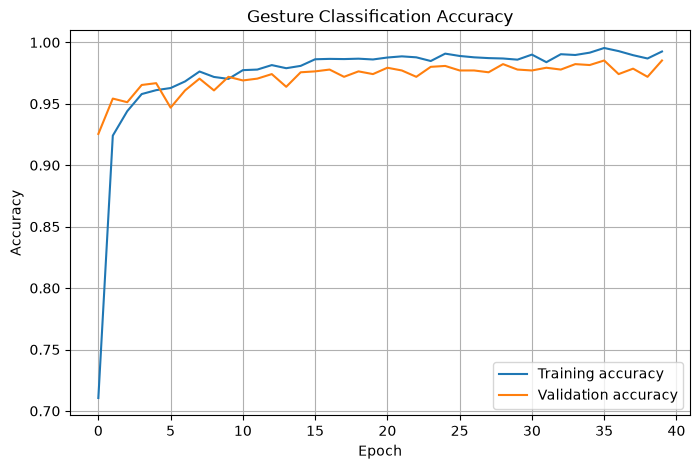

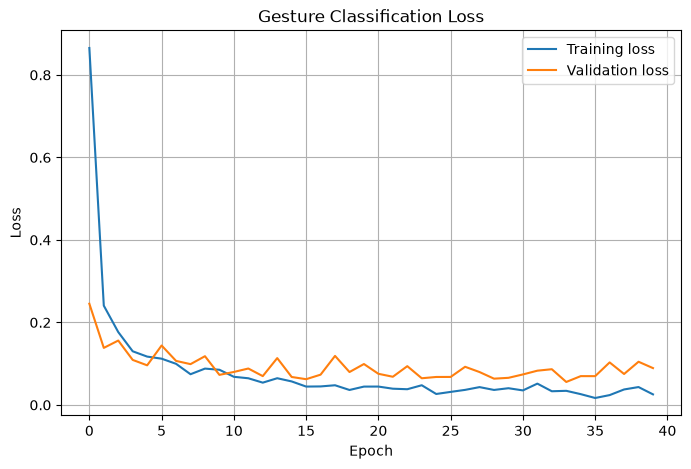

In [97]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=GESTURE_CODES))
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Gesture Classification Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gesture Classification Loss")
plt.legend()
plt.grid(True)
plt.show()


In [98]:
model.save("gesture_cnn_gru_sliding_192.keras")
joblib.dump(scaler, "gesture_scaler_sliding_192.pkl")
print("Saved model as gesture_cnn_gru_resampled.keras")

Saved model as gesture_cnn_gru_resampled.keras


In [99]:
# Check to make sure an even amount of data per class
for gesture, idx in label_map.items():
    print(gesture, np.sum(y == idx))

D 429
De 743
Dn 600
Ds 561
DUD 1083
Dw 641
N 1129
U 1386
Ue 917
Un 454
Uw 1089


In [100]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(test_acc)

print(classification_report(y_test, y_pred, target_names=GESTURE_CODES))
print(confusion_matrix(y_test, y_pred))

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9838 - loss: 0.0606
0.9837638139724731
              precision    recall  f1-score   support

           D       0.94      0.98      0.96        64
          De       0.99      0.97      0.98       111
          Dn       0.96      0.99      0.97        90
          Ds       0.96      0.95      0.96        84
         DUD       0.99      0.99      0.99       163
          Dw       0.98      0.97      0.97        96
           N       0.99      1.00      0.99       170
           U       0.99      1.00      0.99       208
          Ue       0.98      1.00      0.99       138
          Un       1.00      0.94      0.97        68
          Uw       1.00      0.98      0.99       163

    accuracy                           0.98      1355
   macro avg       0.98      0.98      0.98      1355
weighted avg       0.98      0.98      0.98      1355

[[ 63   0   0   0   1   0   0   0   0   0   0]
 [  0 108   0   0   0   2   1   0   0   0   0]
